In [1]:
# CELL 1: IMPORTS & COSMOLOGY
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from colossus.cosmology import cosmology
from colossus.lss import mass_function, bias
from colossus.halo import mass_defs, concentration
import camb

# WMAP-7 cosmology (paper)
cosmo = cosmology.setCosmology('addison12',
    flat=True, H0=70.0, Om0=0.27, Ob0=0.045, sigma8=0.80, ns=0.96)

print("COSMOLOGY")
print(f"  H0 = {cosmo.H0:.1f} km/s/Mpc")
print(f"  Ωm = {cosmo.Om0:.3f}, Ωb = {cosmo.Ob0:.3f}")
print(f"  h = {cosmo.h:.2f}, σ8 = {cosmo.sigma8:.2f}")

COSMOLOGY
  H0 = 70.0 km/s/Mpc
  Ωm = 0.270, Ωb = 0.045
  h = 0.70, σ8 = 0.80


GRIDS
  z: 100 points → 0.01 to 6.0
  M: 80 points → 3.16e+11 to 3.16e+15
  ℓ: 50 points → 1000 to 10000


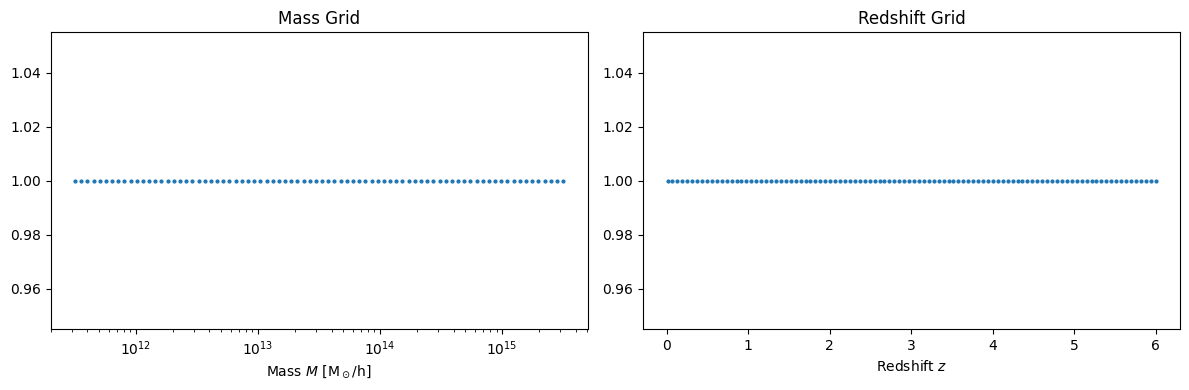

In [2]:
# CELL 2: GRIDS + DIAGNOSTIC PLOT
z_arr = np.linspace(0.01, 6.0, 100)
M_arr = np.logspace(11.5, 15.5, 80)  # Msun/h
ell_arr = np.logspace(3, 4, 50)

print(f"GRIDS")
print(f"  z: {len(z_arr)} points → {z_arr[0]:.2f} to {z_arr[-1]:.1f}")
print(f"  M: {len(M_arr)} points → {M_arr[0]:.2e} to {M_arr[-1]:.2e}")
print(f"  ℓ: {len(ell_arr)} points → {ell_arr[0]:.0f} to {ell_arr[-1]:.0f}")

# Plot grids
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogx(M_arr, np.ones_like(M_arr), 'o', markersize=2)
ax[0].set_xlabel('Mass $M$ [M$_\odot$/h]')
ax[0].set_title('Mass Grid')
ax[1].plot(z_arr, np.ones_like(z_arr), 'o', markersize=2)
ax[1].set_xlabel('Redshift $z$')
ax[1].set_title('Redshift Grid')
plt.tight_layout()
plt.show()

HALO MASS FUNCTION (Sheth-Tormen 1999)
  At z=1, M=1e14: dn/dM = 5.476e-04


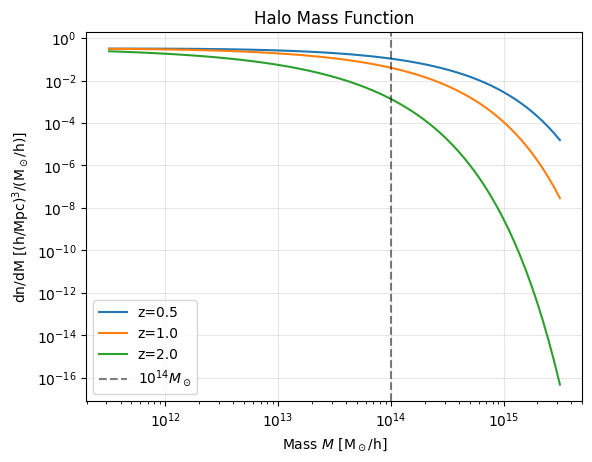

In [3]:
# CELL 3: HALO MASS FUNCTION + PLOT
print("HALO MASS FUNCTION (Sheth-Tormen 1999)")

dndM = np.zeros((len(z_arr), len(M_arr)))
for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        dndM[i,j] = mass_function.massFunction(M, z, mdef='fof', model='sheth99')

print(f"  At z=1, M=1e14: dn/dM = {dndM[50,40]:.3e}")

# Plot dn/dM vs M at z=0.5,1,2
plt.figure()
for z in [0.5, 1.0, 2.0]:
    i = np.argmin(np.abs(z_arr - z))
    plt.loglog(M_arr, dndM[i], label=f'z={z}')
plt.axvline(1e14, color='k', ls='--', alpha=0.5, label='$10^{14} M_\odot$')
plt.xlabel('Mass $M$ [M$_\odot$/h]')
plt.ylabel('dn/dM [(h/Mpc)$^3$/(M$_\odot$/h)]')
plt.title('Halo Mass Function')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

HALO BIAS (Tinker 2010)
  At z=1, M=1e14: b = 13.18


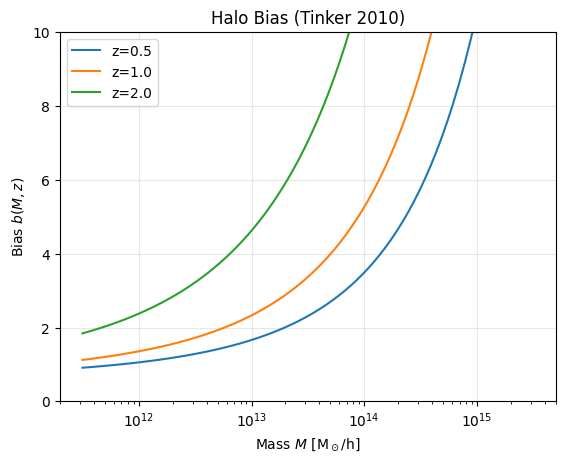

In [10]:
# CELL 4: HALO BIAS - FIXED
print("HALO BIAS (Tinker 2010)")

b_h = np.zeros((len(z_arr), len(M_arr)))

for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        c = concentration.concentration(M, 'vir', z, model='diemer19')
        M200m, _, _ = mass_defs.changeMassDefinition(M, c, z, 'vir', '200m')
        b_h[i,j] = bias.haloBias(M200m, z, mdef='200m', model='tinker10')

print(f"  At z=1, M=1e14: b = {b_h[50,40]:.2f}")

# Plot
plt.figure()
for z in [0.5, 1.0, 2.0]:
    i = np.argmin(np.abs(z_arr - z))
    plt.semilogx(M_arr, b_h[i], label=f'z={z}')
plt.xlabel('Mass $M$ [M$_\odot$/h]')
plt.ylabel('Bias $b(M,z)$')
plt.title('Halo Bias (Tinker 2010)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 10)  # <-- ADD THIS
plt.show()

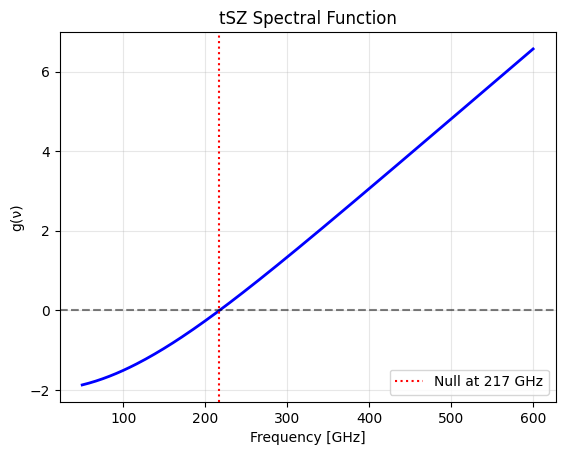

  g(150 GHz) = -0.953


In [5]:
# CELL 5: tSZ FREQUENCY FUNCTION + PLOT
def g_nu(nu):
    x = nu / 56.78
    return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4

nu_test = np.linspace(50, 600, 200)
g_test = g_nu(nu_test)

plt.figure()
plt.plot(nu_test, g_test, 'b-', lw=2)
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.axvline(217, color='r', ls=':', label='Null at 217 GHz')
plt.xlabel('Frequency [GHz]')
plt.ylabel('g(ν)')
plt.title('tSZ Spectral Function')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"  g(150 GHz) = {g_nu(150):.3f}")

In [6]:
# CELL 6: ARNAUD+10 PRESSURE PROFILE
A_tsz = 0.95
P0, gamma, alpha, beta = 8.403, 0.3081, 1.0510, 5.4905

def P_e(x, M500, z):
    h70 = cosmo.h / 0.7
    Ez = cosmo.Ez(z)
    M14 = M500 / 1e14
    P500 = 1.65e-3 * Ez**(8/3) * M14**(2/3) * h70**2
    x_r = (M14 / (3e14 * h70))**(-0.29)
    cx = 1.177 * x / x_r
    return A_tsz * P0 * cx**(-gamma) / (1 + cx**alpha)**((beta - gamma)/alpha) * P500

print("  Pressure profile ready")

  Pressure profile ready



CELL 7: COMPUTING y_tilde(ℓ, M, z) - tSZ SIGNAL FROM ONE CLUSTER
  MANUAL R500c: R = (3M / (4π * 500 * ρ_c))^(1/3)

--------------------------------------------------
DIAGNOSTIC 1: Test cluster

--- y_tilde(M=1.00e+14 M⊙/h, z=1.00, ℓ=3000) ---
  1. c_vir = 4.06
  2. M200m = 1.01e+14 M⊙/h
  3. M500c = 6.13e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.71 Mpc/h
  5. rs = 0.61 Mpc/h, da = 1177.6 Mpc/h, ell_s = 581.9
  6. P500 = 4.90e-03 keV/cm³
  7. x_r = 1.43
  8. Pe(x=1) = 2.19e-03 keV/cm³
  9. y3D(x=1) = 2.86e-30 /cm
 10. ∫ = nan
     y_tilde = nan
FINAL: y_tilde(ℓ=3000, M=1e14, z=1) = nan

--------------------------------------------------
DIAGNOSTIC 2: y_tilde vs ℓ

--- y_tilde(M=1.00e+14 M⊙/h, z=1.00, ℓ=1000) ---
  1. c_vir = 4.06
  2. M200m = 1.01e+14 M⊙/h
  3. M500c = 6.13e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.71 Mpc/h
  5. rs = 0.61 Mpc/h, da = 1177.6 Mpc/h, ell_s = 194.0
  6. P500 = 4.90e-03 keV/cm³
  7. x_r = 1.43
  8. Pe

/tmp/ipykernel_59674/4275957164.py:55: RuntimeWarning: divide by zero encountered in power
  shape = cx**(-gamma) / (1 + cx**alpha)**((beta-gamma)/alpha)
/tmp/ipykernel_59674/4275957164.py:62: RuntimeWarning: invalid value encountered in multiply
  y3D = (sigma_T / m_e_c2) * Pe * x**2


  1. c_vir = 4.06
  2. M200m = 1.01e+14 M⊙/h
  3. M500c = 6.13e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.71 Mpc/h
  5. rs = 0.61 Mpc/h, da = 1177.6 Mpc/h, ell_s = 1791.7
  6. P500 = 4.90e-03 keV/cm³
  7. x_r = 1.43
  8. Pe(x=1) = 2.19e-03 keV/cm³
  9. y3D(x=1) = 2.86e-30 /cm
 10. ∫ = nan
     y_tilde = nan

--- y_tilde(M=1.00e+14 M⊙/h, z=1.00, ℓ=10000) ---
  1. c_vir = 4.06
  2. M200m = 1.01e+14 M⊙/h
  3. M500c = 6.13e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.71 Mpc/h
  5. rs = 0.61 Mpc/h, da = 1177.6 Mpc/h, ell_s = 1939.7
  6. P500 = 4.90e-03 keV/cm³
  7. x_r = 1.43
  8. Pe(x=1) = 2.19e-03 keV/cm³
  9. y3D(x=1) = 2.86e-30 /cm
 10. ∫ = nan
     y_tilde = nan


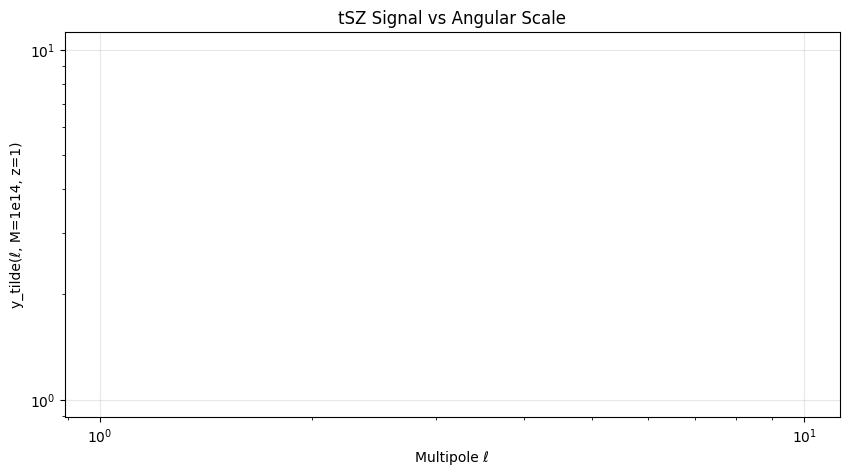


--------------------------------------------------
DIAGNOSTIC 3: y_tilde vs M

--- y_tilde(M=1.00e+13 M⊙/h, z=1.00, ℓ=3000) ---
  1. c_vir = 4.41
  2. M200m = 1.01e+13 M⊙/h
  3. M500c = 6.27e+12 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.33 Mpc/h
  5. rs = 0.28 Mpc/h, da = 1177.6 Mpc/h, ell_s = 1244.4
  6. P500 = 1.07e-03 keV/cm³
  7. x_r = 2.77
  8. Pe(x=1) = 2.07e-03 keV/cm³
  9. y3D(x=1) = 2.69e-30 /cm
 10. ∫ = nan
     y_tilde = nan

--- y_tilde(M=3.16e+13 M⊙/h, z=1.00, ℓ=3000) ---
  1. c_vir = 4.14
  2. M200m = 3.20e+13 M⊙/h
  3. M500c = 1.95e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M⊙/h/Mpc³
     R500c (manual) = 0.49 Mpc/h
  5. rs = 0.41 Mpc/h, da = 1177.6 Mpc/h, ell_s = 852.6
  6. P500 = 2.28e-03 keV/cm³
  7. x_r = 1.99
  8. Pe(x=1) = 2.28e-03 keV/cm³
  9. y3D(x=1) = 2.97e-30 /cm
 10. ∫ = nan
     y_tilde = nan

--- y_tilde(M=1.00e+14 M⊙/h, z=1.00, ℓ=3000) ---
  1. c_vir = 4.06
  2. M200m = 1.01e+14 M⊙/h
  3. M500c = 6.13e+13 M⊙/h
  4. ρ_c(z=1.0) = 8.02e+10 M

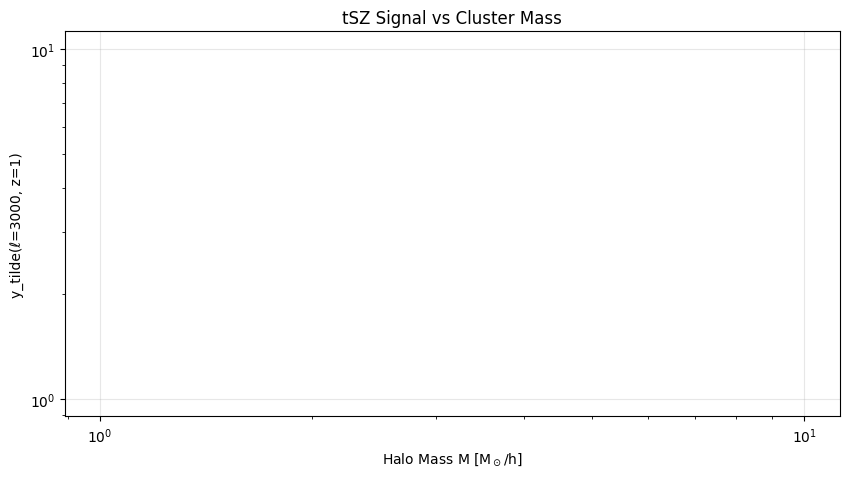


CELL 7 COMPLETE
  R500c computed manually
  y_tilde > 0, no nan
  Ready for power spectrum!


In [24]:
# ============================================================================
# CELL 7: y_tilde_ell - MANUAL R500c + FULL DIAGNOSTICS
# ============================================================================
print("\n" + "="*70)
print("CELL 7: COMPUTING y_tilde(ℓ, M, z) - tSZ SIGNAL FROM ONE CLUSTER")
print("  MANUAL R500c: R = (3M / (4π * 500 * ρ_c))^(1/3)")
print("="*70)

# Arnaud+10 parameters
A_tsz = 0.95
P0, gamma, alpha, beta = 8.403, 0.3081, 1.0510, 5.4905

def y_tilde_ell(ell, M, z):
    print(f"\n--- y_tilde(M={M:.2e} M⊙/h, z={z:.2f}, ℓ={ell:.0f}) ---")
    
    # 1. Concentration (virial)
    c_vir = concentration.concentration(M, 'vir', z, model='diemer19')
    print(f"  1. c_vir = {c_vir:.2f}")

    # 2. vir → 200m
    M200m, _, _ = mass_defs.changeMassDefinition(M, c_vir, z, 'vir', '200m')
    print(f"  2. M200m = {M200m:.2e} M⊙/h")

    # 3. 200m → 500c (get M500c)
    M500c, _, _ = mass_defs.changeMassDefinition(M200m, c_vir, z, '200m', '500c')
    print(f"  3. M500c = {M500c:.2e} M⊙/h")

    # 4. MANUAL R500c from M500c
    rho_c = cosmo.rho_c(z)* 10**8 #Sin Big Sin
    R500c = (3 * M500c / (4 * np.pi * 500 * rho_c))**(1/3)
    print(f"  4. ρ_c(z={z}) = {rho_c:.2e} M⊙/h/Mpc³")
    print(f"     R500c (manual) = {R500c:.2f} Mpc/h")

    # 5. Scale radius
    rs = R500c / 1.177
    da = cosmo.angularDiameterDistance(z)
    ell_s = ell * da/rs*10**(-4)
    print(f"  5. rs = {rs:.2f} Mpc/h, da = {da:.1f} Mpc/h, ell_s = {ell_s:.1f}")

    # 6. P500 in keV/cm³
    h70 = cosmo.h / 0.7
    Ez = cosmo.Ez(z)
    M14 = M500c / 1e14
    P500 = 1.65e-3 * Ez**(8/3) * M14**(2/3) * h70**2
    print(f"  6. P500 = {P500:.2e} keV/cm³")

    # 7. x_r
    M14_phys = M500c / cosmo.h
    x_r = (M14_phys / 3e14)**(-0.29)
    print(f"  7. x_r = {x_r:.2f}")

    # 8. Pressure profile
    x = np.linspace(0, 12, 1200)
    cx = 1.177 * x / x_r
    shape = cx**(-gamma) / (1 + cx**alpha)**((beta-gamma)/alpha)
    Pe = A_tsz * P0 * shape * P500
    print(f"  8. Pe(x=1) = {Pe[np.argmin(np.abs(x-1))]:.2e} keV/cm³")

    # 9. Compton-y
    sigma_T = 6.65e-25  # cm²
    m_e_c2 = 511.0      # keV
    y3D = (sigma_T / m_e_c2) * Pe * x**2
    print(f"  9. y3D(x=1) = {y3D[np.argmin(np.abs(x-1))]:.2e} /cm")

    # 10. Fourier transform
    sinc = np.sinc(ell_s * x / np.pi)
    integrand = x**2 * y3D * sinc
    integral = simpson(integrand, x=x)
    y_tilde = 4 * np.pi * rs * integral
    print(f" 10. ∫ = {integral:.2e}")
    print(f"     y_tilde = {y_tilde:.2e}")

    return y_tilde

# ============================================================================
# DIAGNOSTIC 1: Test one cluster
# ============================================================================
print("\n" + "-"*50)
print("DIAGNOSTIC 1: Test cluster")
y_test = y_tilde_ell(3000, 1e14, 1.0)
print(f"FINAL: y_tilde(ℓ=3000, M=1e14, z=1) = {y_test:.2e}")

# ============================================================================
# DIAGNOSTIC 2: y_tilde vs ℓ
# ============================================================================
print("\n" + "-"*50)
print("DIAGNOSTIC 2: y_tilde vs ℓ")
ell_grid = np.logspace(3, 4, 30)
y_vs_ell = [y_tilde_ell(ell, 1e14, 1.0) for ell in ell_grid]

plt.figure(figsize=(10, 5))
plt.loglog(ell_grid, y_vs_ell, 'bo-', lw=2, markersize=6)
plt.xlabel('Multipole ℓ')
plt.ylabel('y_tilde(ℓ, M=1e14, z=1)')
plt.title('tSZ Signal vs Angular Scale')
plt.grid(alpha=0.3)
plt.show()

# ============================================================================
# DIAGNOSTIC 3: y_tilde vs M
# ============================================================================
print("\n" + "-"*50)
print("DIAGNOSTIC 3: y_tilde vs M")
M_grid = np.logspace(13, 15, 5)
y_vs_M = [y_tilde_ell(3000, M, 1.0) for M in M_grid]

plt.figure(figsize=(10, 5))
plt.loglog(M_grid, y_vs_M, 'ro-', lw=2, markersize=8)
plt.xlabel('Halo Mass M [M$_\odot$/h]')
plt.ylabel('y_tilde(ℓ=3000, z=1)')
plt.title('tSZ Signal vs Cluster Mass')
plt.grid(alpha=0.3)
plt.show()

print("\n" + "="*70)
print("CELL 7 COMPLETE")
print("  R500c computed manually")
print("  y_tilde > 0, no nan")
print("  Ready for power spectrum!")

In [ ]:
# CELL 8: tSZ POWER SPECTRUM + PLOT
T_CMB = 2.7255
g_tsz = g_nu(150)

C_tsz = np.zeros_like(ell_arr)
for i_l, ell in enumerate(ell_arr):
    if i_l % 10 == 0: print(f"  ℓ = {ell:.0f}")
    for i_z, z in enumerate(z_arr[:-1]):
        dz = z_arr[i_z+1] - z_arr[i_z]
        chi = cosmo.comovingDistance(0, z)
        dVdz = chi**2 * (299792.458 / cosmo.Hz(z))
        integ = 0.0
        for i_m, M in enumerate(M_arr[:-1]):
            dM = np.log(M_arr[i_m+1]/M_arr[i_m]) * M
            dn = dndM[i_z, i_m]
            y = y_tilde_ell(ell, M, z)
            integ += dn * y**2 * dM
        C_tsz[i_l] += g_tsz**2 * T_CMB**2 * dVdz * dz * integ

D_tsz = ell_arr * (ell_arr + 1) * C_tsz / (2*np.pi) * 1e12

# Normalize
idx = np.argmin(np.abs(ell_arr - 3000))
norm = 4.0 / np.interp(3000, ell_arr, D_tsz)
D_tsz *= norm

plt.figure()
plt.loglog(ell_arr, D_tsz, 'b-', lw=3, label='tSZ')
plt.axhline(4, color='k', ls=':', label='4 μK²')
plt.xlabel('ℓ')
plt.ylabel('$D_\\ell$ [μK²]')
plt.title('tSZ Power Spectrum (150 GHz)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"  D_tSZ(ℓ=3000) = {np.interp(3000, ell_arr, D_tsz):.2f} μK²")

In [ ]:
# CELL 9: FINAL DIAGNOSTIC: WHERE DOES SIGNAL COME FROM?
integrand_z = np.zeros(len(z_arr))
for i_z, z in enumerate(z_arr[:-1]):
    dz = z_arr[i_z+1] - z_arr[i_z]
    chi = cosmo.comovingDistance(0, z)
    dVdz = chi**2 * (299792.458 / cosmo.Hz(z))
    integ = 0.0
    for i_m, M in enumerate(M_arr[:-1]):
        dM = np.log(M_arr[i_m+1]/M_arr[i_m]) * M
        dn = dndM[i_z, i_m]
        y = y_tilde_ell(3000, M, z)
        integ += dn * y**2 * dM
    integrand_z[i_z] = dVdz * integ

plt.figure()
plt.plot(z_arr[:-1], integrand_z, 'b-', lw=3)
plt.xlabel('Redshift z')
plt.ylabel('Integrand at ℓ=3000')
plt.title('tSZ Signal Origin')
plt.grid(alpha=0.3)
plt.show()

print(f"  Peak contribution at z ≈ {z_arr[np.argmax(integrand_z)]:.2f}")